
To capture universal speaker-independent acoustic characteristics, a Universal Background Model (UBM) is trained on background speech data using a Gaussian Mixture Model (GMM) configured with $K = 32$ Gaussian components. The marginal likelihood of an $d$-dimensional feature vector $x_t$ under the UBM is expressed as:$$p(x_t) = \sum_{k=1}^{K} w_k \mathcal{N}(x_t \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)  $$where $w_k$, $\boldsymbol{\mu}_k$, and $\boldsymbol{\Sigma}_k$ represent the mixture weight, mean vector, and covariance matrix of the $k$-th Gaussian component, respectively.this repesent probility that x exist among these gaussian Each of the 32 Gaussians models a distinct sub-region of the acoustic space, representing shared spectral traits such as pitch registers, formant configurations, and vocal tract length traits. Rather than using hard frame assignments, soft assignment via posterior probabilities (responsibilities) $r_{k,t}$ ensures the framework remains probabilistic:$$r_{k,t} = P(k \mid x_t) = \frac{w_k \mathcal{N}(x_t \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_{j=1}^{K} w_j \mathcal{N}(x_t \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}$$Using these posterior alignments, zero-th and first-order Baum-Welch statistics are extracted from utterance audio frames to adapt the UBM parameters. The adapted mean vectors from all 32 Gaussian components are concatenated to form a high-dimensional GMM mean supervector $M$. Under Total Variability Factorization, $M$ is decomposed into the speaker-independent UBM mean supervector $m$ plus a low-rank subspace shift:$$M = m + T w$$where $T$ is the low-rank Total Variability matrix and $w \sim \mathcal{N}(0, I)$ is the latent vector—commonly known as the i-vector. The i-vector $w$ serves as a compact, low-dimensional representation that jointly captures speaker identity and channel variability derived from the shifted Gaussian means.Once extracted, these i-vectors are evaluated across several downstream classification and scoring backends to compare speaker verification performance. The benchmarking pipeline evaluates traditional machine learning algorithms—such as Linear SVM, RBF-kernel SVM, Random Forest, and a Deep Neural Network (MLP)—against domain-standard acoustic scoring methods, specifically Probabilistic Linear Discriminant Analysis (PLDA) and Cosine Similarity Analysis.

we are using anime vox dataset and implementing directly through hugging face

In [ ]:
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("taresh18/AnimeVox")

# Access the training split
train_data = dataset["train"]

# Print dataset information
print(f"Dataset contains {len(train_data)} samples")

# Access a specific sample
sample = train_data[0]
print(f"Character: {sample['character_name']}")
print(f"From anime: {sample['anime']}")
print(f"Transcription: {sample['transcription']}")

In [ ]:
import numpy as np
import librosa
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.mixture import GaussianMixture
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from scipy.special import logsumexp
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import os

counter is a inbuild which counts the unique label and there sizes
we first are filtering character with less smaples
we are keeping their indexes in keep index then creating a new dataset with those charaters

In [ ]:
# ============================================================
# STEP 1: Filter characters with too few samples
# ============================================================
label_counts = Counter(train_data['character_name'])
valid_chars = {c for c, n in label_counts.items() if n >= 5}
keep_idx = [i for i, c in enumerate(train_data['character_name']) if c in valid_chars]
filtered_data = train_data.select(keep_idx)
print(f"Kept {len(valid_chars)} characters, {len(filtered_data)} samples")


Kept 19 characters, 11020 samples


splitting the data into train and test<br>
stratify ensure that we pick 0.8 for test and 0.2 for each character<br>
ques) why we splitting so -> Splitting early matters immensely because it prevents data leakage.<br>
 we are only giving the index and there labels<br>
we are going to find train_idx and test_idx and they from the last filtererd dataset we<br> are selecting new two data set<br>



In [ ]:
# ============================================================
# STEP 2: Stratified train/test split
# ============================================================
indices = list(range(len(filtered_data)))
labels = filtered_data['character_name']
train_idx, test_idx = train_test_split(indices, test_size=0.2, stratify=labels, random_state=42)
train_split = filtered_data.select(train_idx)
test_split = filtered_data.select(test_idx)
print(f"Train: {len(train_split)} samples | Test: {len(test_split)} samples")

Train: 8816 samples | Test: 2204 samples


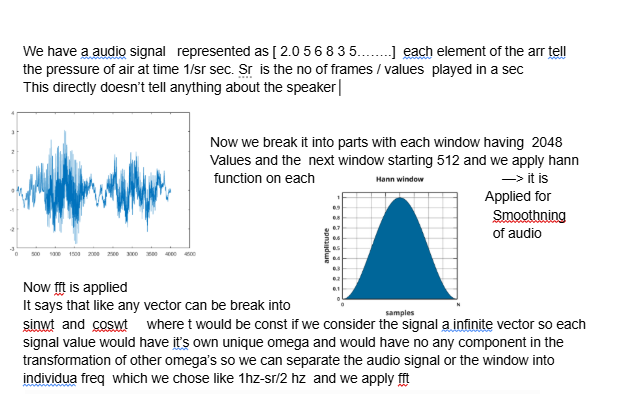

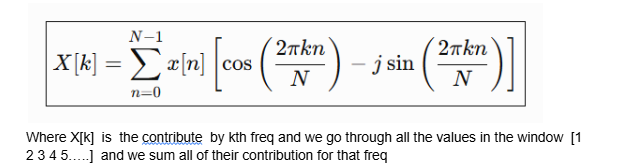

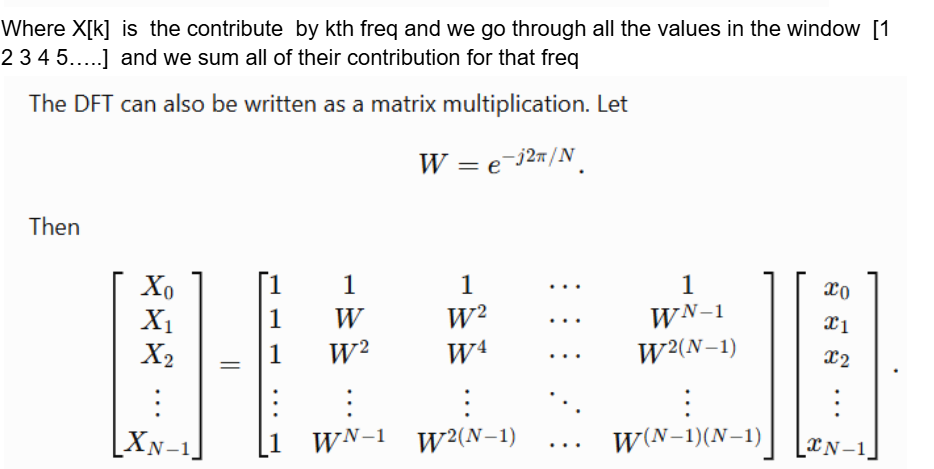

Row 0 computes the DC (0 Hz) component, so all entries are 111.
Row 1 computes the first frequency bin using powers of W
.Row 2 computes the second frequency bin using powers of W^2, and so on


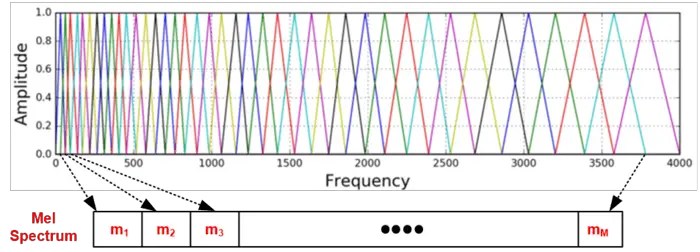

Mel filter banks are based on how humans hear sound. We do not perceive frequency linearly—we hear it approximately logarithmically. At low frequencies, we can easily distinguish small changes (e.g., 200 Hz vs. 300 Hz), but at high frequencies, the same 100 Hz difference (e.g., 5000 Hz vs. 5100 Hz) is barely noticeable. Therefore, Mel filter banks use narrow filters at low frequencies and wider filters at high frequencies, grouping more high-frequency values into a single band while keeping finer resolution where our ears are more sensitive. This makes the audio representation closer to human hearing
Suppose one Mel filter is centered at 1100 Hz. Instead of simply adding all the powers, the filter gives higher importance to frequencies near its center and lower importance to frequencies near its edges.
Why not just sum everything equally?
The triangular weights solve this problem by making adjacent Mel filters overlap. A frequency near the boundary contributes partly to one Mel band and partly to the next, giving a much smoother and more stable representation.
We then take log fortwo purposes simultaneously: it compresses the energies the way our ears perceive loudness (roughly logarithmic, same idea as the mel scale itself), and — this is the part that connects to your source/filter question — it turns a multiplication into an addition.Your vocal folds produce a buzzy pulse train (the source — this is where fundamental frequency/pitch and its harmonics live). That pulse passes through your vocal tract, which acts as a resonant filter (shaped by tongue position, jaw, lips, and yes, vocal tract length) that boosts some frequencies (formants) and damps others. In the time domain this is convolution; in the frequency domain, convolution becomes multiplication: Spectrum(f) = Source(f) × Filter(f). Nasal sounds work the same way but the filter also picks up extra anti-resonances (zeros) from the nasal cavity being coupled in, which is why nasal spectra look different — that's more filter shape, not source.

Taking the log turns that product into a sum: log(Spectrum) = log(Source) + log(Filter). Now the two things you actually want to separate are just added together, which sets up the next step.




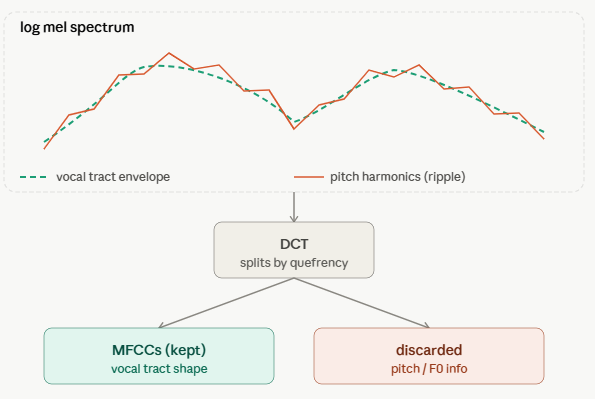

So what do MFCCs actually store? Mostly the vocal tract's resonant shape at that instant — which is what makes a vowel sound like that vowel, and which also carries some speaker identity (vocal tract length and articulator size shift formant positions even for the "same" phoneme). What they deliberately throw away is F0/pitch, which is why MFCCs are relatively pitch-independent — useful for phoneme/word recognition

107428


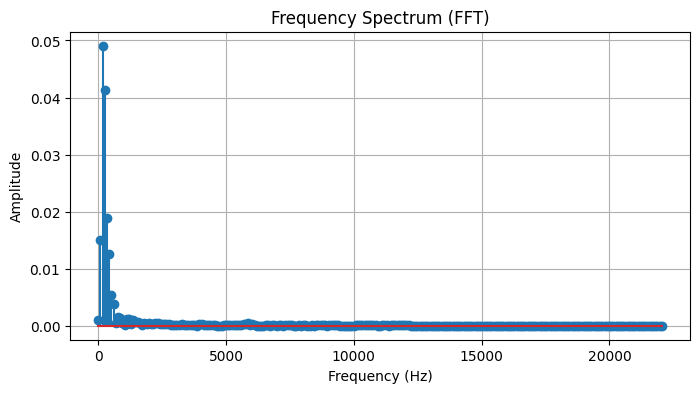

[-1.00615587e+02  1.53000946e+01  6.13508412e+00  4.05199184e+00
  2.85986299e+00  2.88236094e+00  1.83821358e+00  5.94991006e-01
  5.43504791e-02  1.42564082e-01 -6.99682254e-01 -7.22478377e-01
  8.74169685e-02]


In [ ]:
import matplotlib.pyplot as plt
import librosa
import numpy as np
sample = train_data[500]
audio_data1 = sample['audio']['array']
sampling_rate1 = sample['audio']['sampling_rate']

print(audio_data1.size)
f=0
framelength=512
hooplegth=160
anew=audio_data1[f:f+framelength]
window = np.hanning(framelength)
windowframe = anew * window
fft = np.fft.rfft(windowframe) #even 512 error of 1 n/2+1 we take negitive last and remove it so rrft better

frequencies = np.fft.rfftfreq(framelength, d=1/sampling_rate1)

magnitude = np.abs(fft) * 2 / framelength
magnitude[0] /= 2
magnitude[-1] /= 2   # Nyquist bin should also not be doubled

    # steven buston video

  # into 2 becaue of negitive values

plt.figure(figsize=(8, 4))
plt.stem(frequencies[frequencies>=0], magnitude)

  # do we take power do we divide by n do we take log after that i don't know

plt.title("Frequency Spectrum (FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")

plt.grid(True)
plt.show()
power = magnitude ** 2
fban= librosa.filters.mel(sr=sampling_rate1, n_fft=framelength, n_mels=26)
mel_values = np.dot(fban, power)
log_mel = np.log(mel_values + 1e-10)  # small epsilon to avoid log(0)
from scipy.fft import dct
mfcc_coeffs = dct(log_mel, type=2, norm='ortho')[:13]
print(mfcc_coeffs)

if audio array is empty or not finite or sr is null we won't be using those mfcc

In [ ]:

# ============================================================
# STEP 3: Feature extraction
# ============================================================
def extract_features(audio_array, sr, n_mfcc=13, n_fft=512, hop_length=160):
    if audio_array is None or len(audio_array) == 0:
        return None
    if not np.isfinite(audio_array).all():
        return None
    if not sr or sr <= 0:
        return None
    try:
        mfcc = librosa.feature.mfcc(y=audio_array.astype(np.float32), sr=sr,
                                     n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
        if mfcc.size == 0:
            return None
        delta = librosa.feature.delta(mfcc, order=1)
        delta2 = librosa.feature.delta(mfcc, order=2)
        return np.vstack([mfcc, delta, delta2]).T
    except Exception as e:
        print(f"  [skip] feature extraction failed: {e}")
        return None


we are not collecting all the mfcc and their corresponding labels for all the audio present in training and testing

In [ ]:
def extract_split(split, name="split"):
    feats_list, labels_list = [], []
    skipped = 0
    n = len(split)
    for i in range(n):
        sample = split[i]
        feats = extract_features(sample['audio']['array'], sample['audio']['sampling_rate'])
        if feats is None or feats.shape[0] == 0:
            skipped += 1
        else:
            feats_list.append(feats)
            labels_list.append(sample['character_name'])
        if (i + 1) % 500 == 0 or (i + 1) == n:
            print(f"  [{name}] {i + 1}/{n} processed")
    print(f"[{name}] extracted {len(feats_list)}, skipped {skipped}")
    return feats_list, labels_list


this is to make the process the faster if there avaiblable cache stored we will use that

In [ ]:
FEATURES_CACHE = "gmm_uba_features_cache.npz"

if   os.path.exists(FEATURES_CACHE):
    print(f"Loading cached features from {FEATURES_CACHE}")
    cache = np.load(FEATURES_CACHE, allow_pickle=True)
    train_features, train_labels = list(cache['train_features']), list(cache['train_labels'])
    test_features, test_labels = list(cache['test_features']), list(cache['test_labels'])
else:
    print("!! No cache found — this will redo full feature extraction !!")
    train_features, train_labels = extract_split(train_split, "train")
    test_features, test_labels = extract_split(test_split, "test")
    np.savez(FEATURES_CACHE,
             train_features=np.array(train_features, dtype=object),
             train_labels=np.array(train_labels, dtype=object),
             test_features=np.array(test_features, dtype=object),
             test_labels=np.array(test_labels, dtype=object))
    print(f"Cached features to {FEATURES_CACHE}")

if after filtering any character has less items we will drop them

In [ ]:

train_label_counts = Counter(train_labels)
still_valid = {c for c, n in train_label_counts.items() if n >= 2}
if len(still_valid) < len(set(train_labels)):
    dropped = set(train_labels) - still_valid
    print(f"Dropping {len(dropped)} characters below minimum: {dropped}")
    keep = [i for i, l in enumerate(train_labels) if l in still_valid]
    train_features = [train_features[i] for i in keep]
    train_labels = [train_labels[i] for i in keep]
    keep_test = [i for i, l in enumerate(test_labels) if l in still_valid]
    test_features = [test_features[i] for i in keep_test]
    test_labels = [test_labels[i] for i in keep_test]

we are now going to normalize all the mfcc 39 feature all together because **Their brightness difference might actually contain useful information.If you normalize each image independently, you remove those global intensity differences.Sometimes that's useful,but often it throws away information.That's why dataset normalization and BatchNorm are designed differently. **
Maybe if one image if more darker than than the first one however if do mean and standard deviation individual compared to individual image the lighter parts will have similar value like 0.03 0.04 however there are more darker compared to picture 2 and we will loss this information


In [ ]:

# ============================================================
# STEP 5: Fit scaler on TRAIN only
# ============================================================
stacked_train = np.vstack(train_features)
scaler = StandardScaler()
scaler.fit(stacked_train)
train_features_scaled = [scaler.transform(f) for f in train_features]
test_features_scaled = [scaler.transform(f) for f in test_features]

encoder = LabelEncoder()
train_labels = encoder.fit_transform(train_labels)

test_labels = encoder.transform(test_labels)

# keeping a decoded (string) copy of the true test labels around.

test_labels_str = encoder.inverse_transform(test_labels)


N_UBM_COMPONENTS = 32<br>
MAX_UBM_FRAMES = 300_000 —--> we get like each audio ok like 39 feauture per frames each audio have like 698 frames and like <br> (39,11200*698)around 7817600 which is a lot to we only use 3000000  


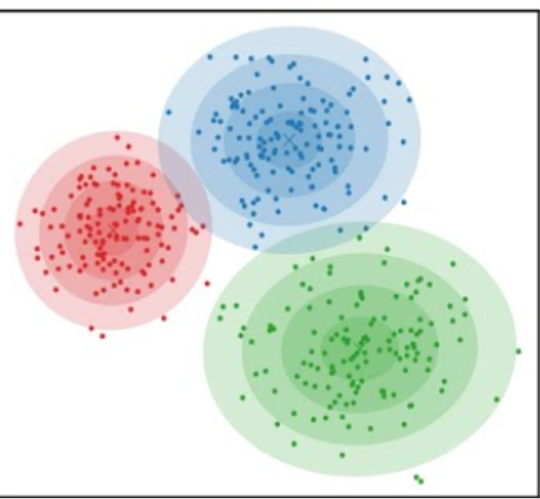

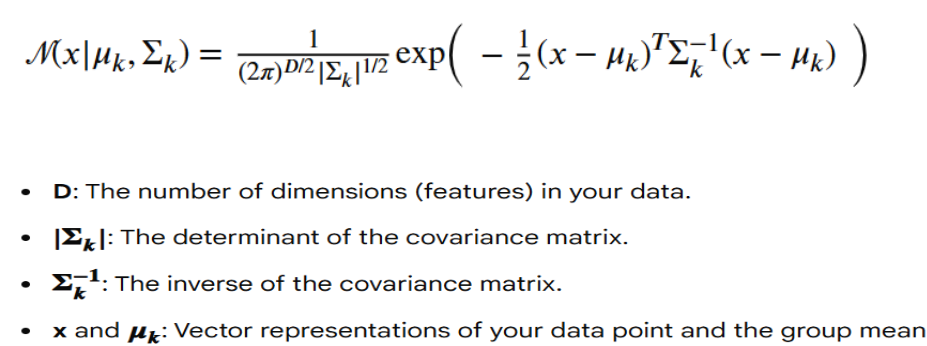

We trained a 32-component Gaussian Mixture Model (GMM) on our speech dataset (which contains 11,200 * 698 samples, each with 39 features) to model average human speech. The model's output consists of 32 Gaussian components, each defined by three parameters: a mixture weight, a 39-dimensional mean vector, and a 39-dimensional diagonal variance vector.

To illustrate this with a smaller example using 3 Gaussian components and 2 features, the output structure—formatted as [ [weight, [mean vector], [variance vector]], ... ]—looks like this:
[ [0.3, [1, 2], [2, 3]], [0.5, [5, 8], [4, 5]], [0.2, [11, 12], [6, 9]] ]

Likelihood in probability and Gaussian Mixture Models (GMMs) measures how plausible a specific observed data point (such as an audio frame with feature vector $\mathbf{x}$) is under a given statistical model. In simple terms, if you have a Gaussian distribution defined by a mean $\boldsymbol{\mu}$ and variance $\boldsymbol{\sigma}^2$, the likelihood tells you the height of the probability density curve at point $\mathbf{x}$. A higher likelihood means the frame fits that specific Gaussian component well, whereas a lower likelihood means the point is an outlier for that component. When working with multiple components, the overall likelihood of a frame is the weighted sum of its likelihoods across all individual Gaussian components.Precision is simply the inverse of variance ($\mathbf{p} = \frac{1}{\boldsymbol{\sigma}^2}$). While variance measures the spread or uncertainty of a feature (how wide the bell curve is), precision measures tightness or certainty (how sharp the peak is). High variance means low precision, meaning data points can be far from the mean without a severe penalty. Conversely, high precision heavily penalizes any frame whose features stray even slightly from the mean vector. Using precision in code simplifies matrix calculations because division operations are transformed into faster, vectorizable multiplication operations.Step-by-Step Breakdown of the Code1. Calculating Gaussian Log-Probabilities (diag_gaussian_log_prob)The continuous multivariate Gaussian probability density function for a diagonal covariance matrix is defined as:$$p(\mathbf{x} \mid \boldsymbol{\mu}, \mathbf{\Sigma}) = \frac{1}{\sqrt{(2\pi)^D \prod_{d=1}^D \sigma_d^2}} \exp\left( -\frac{1}{2} \sum_{d=1}^D \frac{(x_d - \mu_d)^2}{\sigma_d^2} \right)$$To avoid numerical underflow with tiny probabilities, we compute the logarithm of this expression:$$\ln p(\mathbf{x} \mid \boldsymbol{\mu}, \mathbf{\Sigma}) = -\frac{1}{2} \left[ \sum_{d=1}^D \ln(2\pi \sigma_d^2) + \sum_{d=1}^D \frac{(x_d - \mu_d)^2}{\sigma_d^2} \right]$$The function diag_gaussian_log_prob(X, means, covariances) computes this efficiently across all $N$ frames and $K$ components simultaneously using matrix algebra:precisions = 1.0 / covariances: Converts each variance value $\sigma_k^2$ into precision $P_k = \frac{1}{\sigma_k^2}$.log_det = np.sum(np.log(2 * np.pi * covariances), axis=1): Computes the normalization term $\sum_{d=1}^D \ln(2\pi \sigma_{k,d}^2)$ for each Gaussian component $k$, resulting in a vector of length $K$.Expanding $(x - \mu)^2 / \sigma^2$ into $A - 2B + C$:Notice that expanding the quadratic term gives $\frac{x^2 - 2x\mu + \mu^2}{\sigma^2} = x^2 P - 2 x (\mu P) + \mu^2 P$. The code computes these three pieces across all frames and components using matrix multiplication (@):A = (X ** 2) @ precisions.T: Multiplies the squared input features $(N \times D)$ by the precision matrix transposed $(D \times K)$, producing an $(N \times K)$ matrix containing $\sum_d x_{n,d}^2 P_{k,d}$.B = X @ (means * precisions).T: Computes the cross-term $\sum_d x_{n,d} \mu_{k,d} P_{k,d}$ for every frame $n$ and component $k$, returning an $(N \times K)$ matrix.C = np.sum((means ** 2) * precisions, axis=1): Computes the component-wise mean-squared term $\sum_d \mu_{k,d}^2 P_{k,d}$, giving a vector of length $K$.return -0.5 * (A - 2 * B + C[None, :] + log_det[None, :]): Combines $A - 2B + C$ (which equals the squared distance term $(x-\mu)^T \mathbf{\Sigma}^{-1} (x-\mu)$) with the log_det term, returning an $(N \times K)$ matrix of log-probabilities for every frame $n$ and component $k$.2. Computing Responsibilities and Overall Likelihood (gmm_posteriors_and_ll)Once the log-probabilities for each individual Gaussian are calculated, the function gmm_posteriors_and_ll evaluates the entire GMM:weighted_log_prob = log_prob + np.log(weights)[None, :]: Scales the log-probability of each component by adding the log of its mixture weight $\ln(\pi_k)$, computing $\ln(\pi_k \cdot p(\mathbf{x}_n \mid \boldsymbol{\mu}_k, \mathbf{\Sigma}_k))$.log_likelihood = logsumexp(weighted_log_prob, axis=1): Sums the weighted probabilities across all components for each frame $n$: $\ln \left( \sum_{k=1}^K \pi_k p(\mathbf{x}_n \mid \boldsymbol{\mu}_k, \mathbf{\Sigma}_k) \right)$. The logsumexp function performs this sum in log-space to prevent numerical underflow.responsibilities = np.exp(weighted_log_prob - log_likelihood[:, None]): Converts log-space differences back to standard probabilities. For frame $n$ and component $k$, it evaluates:$$\gamma_{n,k} = \frac{\pi_k p(\mathbf{x}_n \mid \boldsymbol{\mu}_k, \mathbf{\Sigma}_k)}{\sum_{j=1}^K \pi_j p(\mathbf{x}_n \mid \boldsymbol{\mu}_j, \mathbf{\Sigma}_j)}$$Each row of the resulting matrix corresponds to a frame, and each column corresponds to a gausian model. The sum of responsibilities across components for a single frame equals $1.0$.Numerical Walkthrough with Your ExampleSuppose we have $N = 3$ frames and $K = 3$ components. The matrix output of responsibilities ($\boldsymbol{\gamma}$) contains the weight assigned to each component for every frame:$$\boldsymbol{\gamma} = \begin{bmatrix}  \gamma_{1,1} & \gamma_{1,2} & \gamma_{1,3} \\  \gamma_{2,1} & \gamma_{2,2} & \gamma_{2,3} \\  \gamma_{3,1} & \gamma_{3,2} & \gamma_{3,3}  \end{bmatrix} =  \begin{bmatrix}  0.1 & 0.2 & 0.7 \\  0.1 & 0.2 & 0.7 \\  0.1 & 0.2 & 0.7  \end{bmatrix}$$Zeroth-Order Statistics ($N_k$)The zeroth-order statistic $N_k$ represents the effective total number of frames assigned to component $k$. It is calculated by summing the responsibilities down each column:$N_1$ $= \gamma_{1,1} + \gamma_{2,1} + \gamma_{3,1} = 0.1 + 0.1 + 0.1 = 0.3$$N_2$ $= \gamma_{1,2} + \gamma_{2,2} + \gamma_{3,2} = 0.2 + 0.2 + 0.2 = 0.6$$N_3$ $= \gamma_{1,3} + \gamma_{2,3} + \gamma_{3,3} = 0.7 + 0.7 + 0.7 = 2.1$First-Order Statistics ($F_k$)The first-order statistic $F_k$ represents the soft-weighted sum of feature vectors assigned to component $k$. Given input feature frames $\mathbf{x}_1 = [1, 2]$, $\mathbf{x}_2 = [4, 5]$, and $\mathbf{x}_3 = [6, 7]$, we weight each frame by its responsibility $\gamma_{n,1}$ for Component 1:Frame 1 contribution: $\gamma_{1,1} \cdot \mathbf{x}_1 = 0.1 \times [1, 2] = [0.1, 0.2]$Frame 2 contribution: $\gamma_{2,1} \cdot \mathbf{x}_2 = 0.1 \times [4, 5] = [0.4, 0.5]$Frame 3 contribution: $\gamma_{3,1} \cdot \mathbf{x}_3 = 0.1 \times [6, 7] = [0.6, 0.7]$Summing these weighted frames gives the overall first-order statistic vector $F_1$:$$F_1 = [0.1, 0.2] + [0.4, 0.5] + [0.6, 0.7] = [1.1, 1.4]$$These accumulated statistics ($N_k$ and $F_k$) are then used in expectation-maximization (EM) or MAP adaptation algorithms to update the mean vector for Component 1 as $\boldsymbol{\mu}_1^{\text{new}} = \frac{F_1}{N_1} = \frac{[1.1, 1.4]}{0.3} \approx [3.67, 4.67]$.

GMM Mean Update and MAP Adaptation1. Given Data & StatisticsInitial Mean ($\boldsymbol{\mu}_{\text{old}}$): $[1, 2]$Occupied Frames ($\mathbf{x}_1, \mathbf{x}_2, \mathbf{x}_3$): $[2, 3]$, $[4, 5]$, $[3, 4]$Occupancy Count ($N$): $3$First-Order Statistic ($F$):$$F = \sum_{i=1}^{3} \mathbf{x}_i = [2, 3] + [4, 5] + [3, 4] = [9, 12]$$2. Standard Maximum Likelihood (ML) UpdateIn standard Expectation-Maximization (EM) training, the new Gaussian mean is simply the sample average of the assigned frames:$$\boldsymbol{\mu}_{\text{ML}} = \frac{F}{N} = \frac{[9, 12]}{3} = [3, 4]$$3. MAP (Maximum A Posteriori) Adaptation UpdateWhen adapting a pretrained Universal Background Model (UBM) mean $\boldsymbol{\mu}_{\text{old}}$ to a specific speaker or dataset with limited frames, we interpolate between the empirical sample mean ($\frac{F}{N}$) and the prior mean ($\boldsymbol{\mu}_{\text{old}}$) using an adaptation weight $\alpha \in [0, 1]$:$$\boldsymbol{\mu}_{\text{new}} = \alpha \left( \frac{F}{N} \right) + (1 - \alpha) \boldsymbol{\mu}_{\text{old}}$$In standard MAP adaptation (e.g., Reynolds adaptation), $\alpha$ is determined by a relevance factor $r$:$$\alpha = \frac{N}{N + r}$$Numerical Example (assuming $\alpha = 0.6$):

In [ ]:
def diag_gaussian_log_prob(X, means, covariances):
    precisions = 1.0 / covariances
    log_det = np.sum(np.log(2 * np.pi * covariances), axis=1)
    A = (X ** 2) @ precisions.T
    B = X @ (means * precisions).T
    C = np.sum((means ** 2) * precisions, axis=1)
    return -0.5 * (A - 2 * B + C[None, :] + log_det[None, :])

def gmm_posteriors_and_ll(X, weights, means, covariances):
    log_prob = diag_gaussian_log_prob(X, means, covariances)
    weighted_log_prob = log_prob + np.log(weights)[None, :]
    log_likelihood = logsumexp(weighted_log_prob, axis=1)
    responsibilities = np.exp(weighted_log_prob - log_likelihood[:, None])
    return responsibilities, log_likelihood

In [ ]:
# ============================================================
# STEP 6: Train (or load cached) UBM
# ============================================================
N_UBM_COMPONENTS = 32
MAX_UBM_FRAMES = 300_000
UBM_CACHE = "ubm_params.npz"

if  os.path.exists(UBM_CACHE):
    print(f"Loading cached UBM from {UBM_CACHE}")
    ubm_cache = np.load(UBM_CACHE)
    ubm_weights, ubm_means, ubm_covariances = ubm_cache['weights'], ubm_cache['means'], ubm_cache['covariances']
else:
    all_train_frames = np.vstack(train_features_scaled)
    print(f"Total pooled training frames: {all_train_frames.shape[0]}")
    if all_train_frames.shape[0] > MAX_UBM_FRAMES:
        rng = np.random.default_rng(42)
        sample_idx = rng.choice(all_train_frames.shape[0], MAX_UBM_FRAMES, replace=False)
        ubm_fit_frames = all_train_frames[sample_idx]
    else:
        ubm_fit_frames = all_train_frames

    print(f"Fitting UBM on {ubm_fit_frames.shape[0]} frames, {N_UBM_COMPONENTS} components...")
    ubm = GaussianMixture(n_components=N_UBM_COMPONENTS, covariance_type='diag',
                           max_iter=100, random_state=42)
    ubm.fit(ubm_fit_frames)
    ubm_weights, ubm_means, ubm_covariances = ubm.weights_, ubm.means_, ubm.covariances_
    np.savez(UBM_CACHE, weights=ubm_weights, means=ubm_means, covariances=ubm_covariances)
    print(f"Cached UBM to {UBM_CACHE}")
print("UBM ready.")

Total pooled training frames: 5978720
Fitting UBM on 300000 frames, 32 components...
Cached UBM to ubm_params.npz
UBM ready.


In [ ]:
# ============================================================
# STEP 7: Compute Baum-Welch statistics per utterance (parallel)
# ============================================================
STATS_CACHE = "baumwelch_stats.npz"

def compute_baum_welch_stats(feats_scaled, ubm_weights, ubm_means, ubm_covariances):
    resp, _ = gmm_posteriors_and_ll(feats_scaled, ubm_weights, ubm_means, ubm_covariances)
    N = resp.sum(axis=0)
    F = resp.T @ feats_scaled - N[:, None] * ubm_means
    return N, F

if os.path.exists(STATS_CACHE):
    print(f"Loading cached Baum-Welch stats from {STATS_CACHE}")
    sc = np.load(STATS_CACHE)
    train_N, train_F, test_N, test_F = sc['train_N'], sc['train_F'], sc['test_N'], sc['test_F']
else:
    def _bw(f):
        return compute_baum_welch_stats(f, ubm_weights, ubm_means, ubm_covariances)

    print("Computing Baum-Welch stats (train)...")
    train_results = Parallel(n_jobs=-1, verbose=5)(delayed(_bw)(f) for f in train_features_scaled)
    print("Computing Baum-Welch stats (test)...")
    test_results = Parallel(n_jobs=-1, verbose=5)(delayed(_bw)(f) for f in test_features_scaled)

    train_N = np.array([r[0] for r in train_results])
    train_F = np.array([r[1] for r in train_results])
    test_N = np.array([r[0] for r in test_results])
    test_F = np.array([r[1] for r in test_results])

    np.savez(STATS_CACHE, train_N=train_N, train_F=train_F, test_N=test_N, test_F=test_F)
    print(f"Cached Baum-Welch stats to {STATS_CACHE}")







In [ ]:
# ============================================================
# STEP 8: Train the Total Variability matrix T via EM
# ============================================================
IVEC_DIM = 50
T_ITER = 5
T_BATCH_SIZE = 500
TMATRIX_CACHE = "total_variability_matrix.npy"

def train_total_variability_matrix(N_all, F_all, ubm_covariances, R=100, n_iter=5,
                                    batch_size=500, random_state=42):
    n_utts, K = N_all.shape
    D = ubm_covariances.shape[1]
    precision = 1.0 / ubm_covariances

    rng = np.random.default_rng(random_state)
    T = rng.normal(scale=1.0 / np.sqrt(R), size=(K, D, R))

    for it in range(n_iter):
        Tc_prec = T * precision[:, :, None]
        G = np.einsum('cdr,cds->crs', Tc_prec, T)

        Numer = np.zeros((K, D, R))
        Denom = np.zeros((K, R, R))

        for start in range(0, n_utts, batch_size):
            end = min(start + batch_size, n_utts)
            N_b = N_all[start:end]
            F_b = F_all[start:end]

            L_b = np.eye(R)[None, :, :] + np.einsum('bc,crs->brs', N_b, G)
            rhs_b = np.einsum('cdr,bcd->br', Tc_prec, F_b)

            L_b_inv = np.linalg.inv(L_b)
            W_b = np.einsum('brs,bs->br', L_b_inv, rhs_b)
            E_ww_b = L_b_inv + np.einsum('br,bs->brs', W_b, W_b)

            Numer += np.einsum('bcd,br->cdr', F_b, W_b)
            Denom += np.einsum('bc,brs->crs', N_b, E_ww_b)

        for c in range(K):
            T[c] = Numer[c] @ np.linalg.inv(Denom[c] + 1e-6 * np.eye(R))

        print(f"[T-matrix EM] iteration {it + 1}/{n_iter} done")

    return T

if os.path.exists(TMATRIX_CACHE):
    print(f"Loading cached T matrix from {TMATRIX_CACHE}")
    T_matrix = np.load(TMATRIX_CACHE)
else:
    print(f"Training Total Variability matrix: R={IVEC_DIM}, iterations={T_ITER}")
    T_matrix = train_total_variability_matrix(
        train_N, train_F, ubm_covariances, R=IVEC_DIM, n_iter=T_ITER, batch_size=T_BATCH_SIZE
    )
    np.save(TMATRIX_CACHE, T_matrix)
    print(f"Cached T matrix to {TMATRIX_CACHE}")

Training Total Variability matrix: R=50, iterations=5
[T-matrix EM] iteration 1/5 done
[T-matrix EM] iteration 2/5 done
[T-matrix EM] iteration 3/5 done
[T-matrix EM] iteration 4/5 done
[T-matrix EM] iteration 5/5 done
Cached T matrix to total_variability_matrix.npy


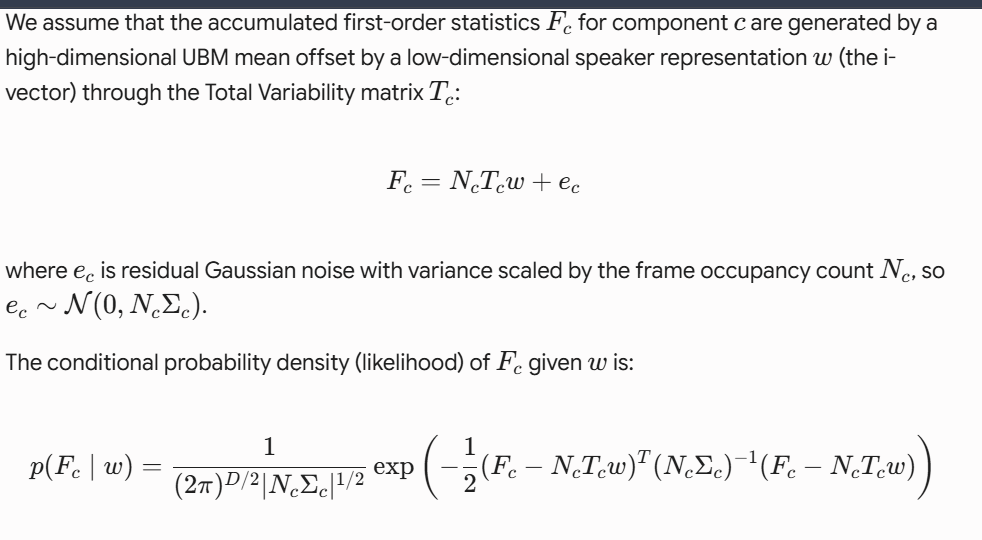

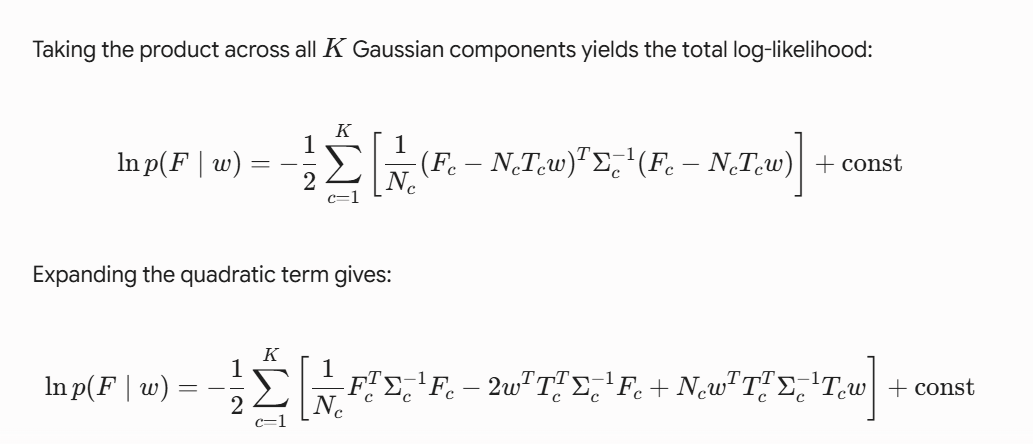

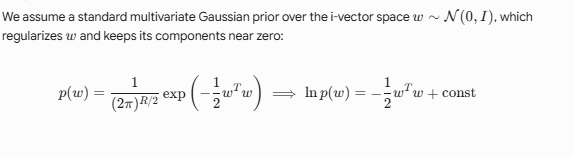

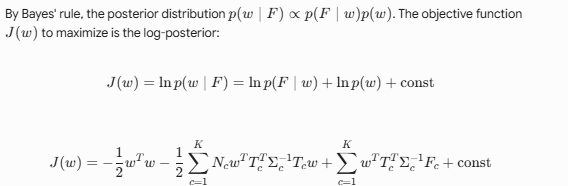

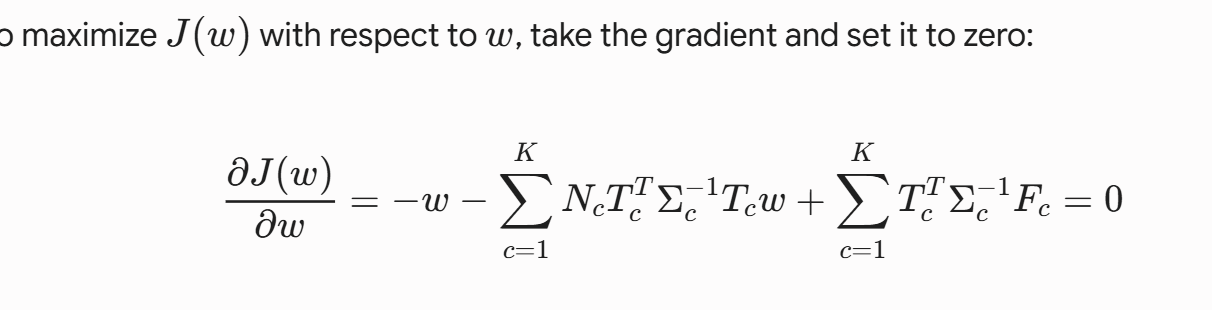

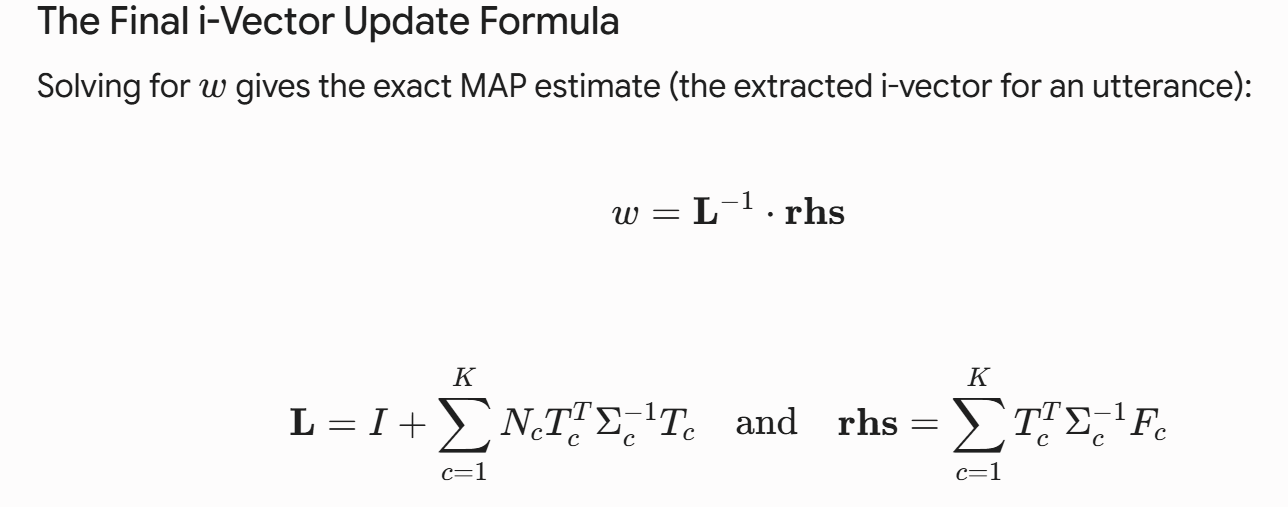

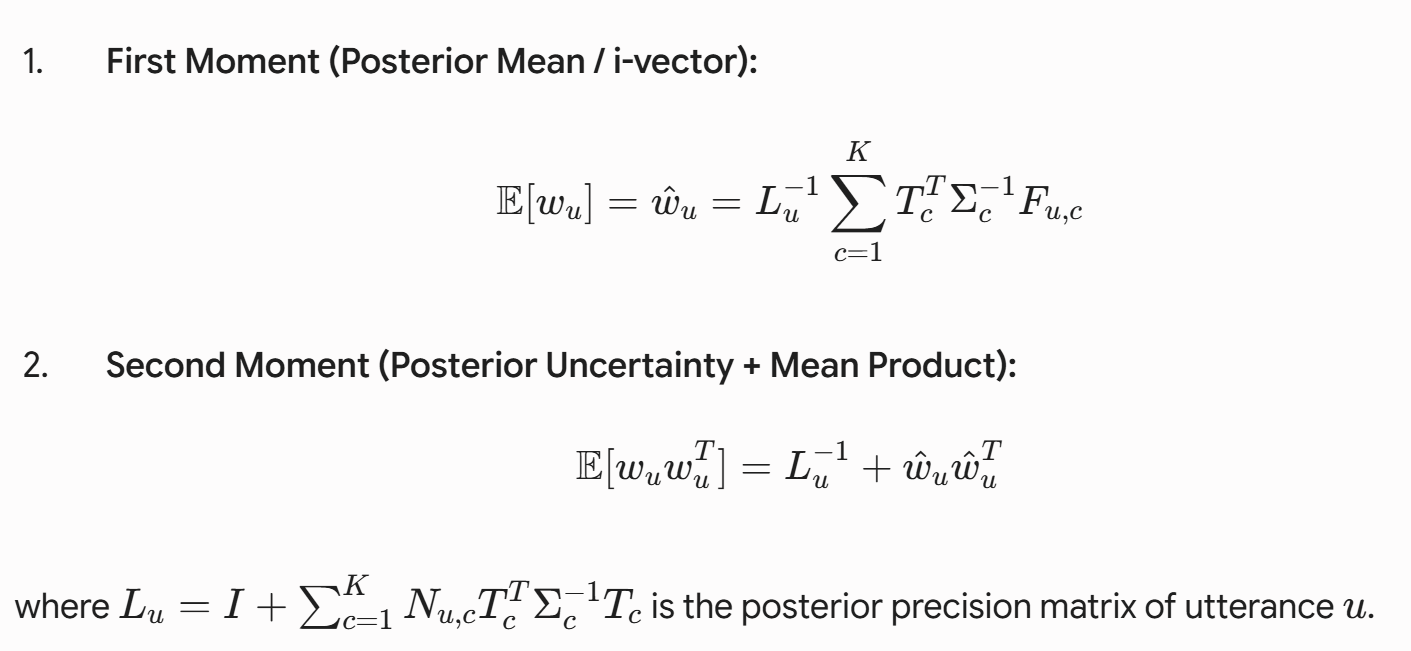

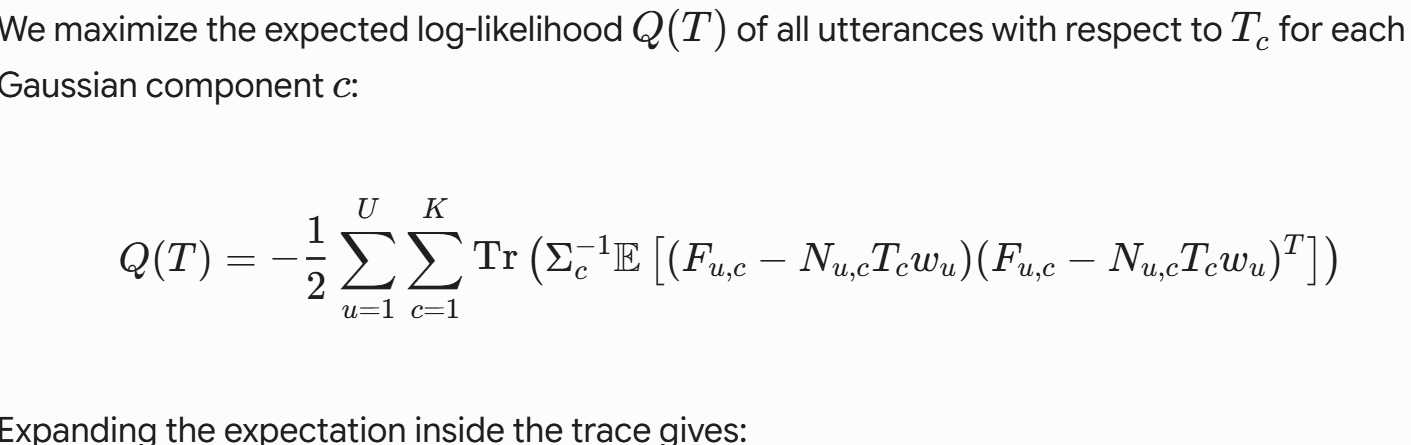

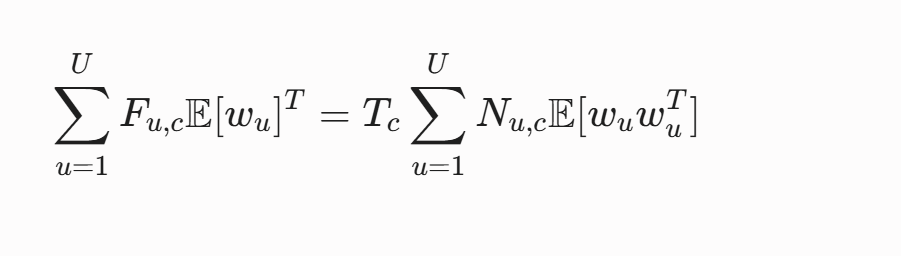

In [ ]:
# ============================================================
# STEP 9: Extract i-vectors for every train/test utterance
# ============================================================
def extract_ivectors(N_all, F_all, T, ubm_covariances, batch_size=500):
    K, D, R = T.shape
    precision = 1.0 / ubm_covariances
    Tc_prec = T * precision[:, :, None]
    G = np.einsum('cdr,cds->crs', Tc_prec, T)

    n_utts = N_all.shape[0]
    ivecs = np.zeros((n_utts, R))
    for start in range(0, n_utts, batch_size):
        end = min(start + batch_size, n_utts)
        N_b = N_all[start:end]
        F_b = F_all[start:end]
        L_b = np.eye(R)[None, :, :] + np.einsum('bc,crs->brs', N_b, G)
        rhs_b = np.einsum('cdr,bcd->br', Tc_prec, F_b)
        L_b_inv = np.linalg.inv(L_b)
        ivecs[start:end] = np.einsum('brs,bs->br', L_b_inv, rhs_b)
    return ivecs
IVEC_CACHE = "ivectors.npz"
if  os.path.exists(IVEC_CACHE):
    print(f"Loading cached i-vectors from {IVEC_CACHE}")
    ic = np.load(IVEC_CACHE, allow_pickle=True)
    train_ivectors, test_ivectors = ic['train_ivectors'], ic['test_ivectors']
else:
    train_ivectors = extract_ivectors(train_N, train_F, T_matrix, ubm_covariances)
    test_ivectors = extract_ivectors(test_N, test_F, T_matrix, ubm_covariances)
    np.savez(IVEC_CACHE, train_ivectors=train_ivectors, test_ivectors=test_ivectors)
    print(f"Cached i-vectors to {IVEC_CACHE}")
print(f"i-vector dimensionality: {train_ivectors.shape[1]}")

Cached i-vectors to ivectors.npz
i-vector dimensionality: 50


In [ ]:

# STEP 10: Center + length-normalize i-vectors
# ============================================================
ivec_mean = train_ivectors.mean(axis=0)
train_ivectors_c = train_ivectors - ivec_mean
test_ivectors_c = test_ivectors - ivec_mean

def length_normalize(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norms, 1e-8)

train_ivectors_norm = length_normalize(train_ivectors_c)
test_ivectors_norm = length_normalize(test_ivectors_c)

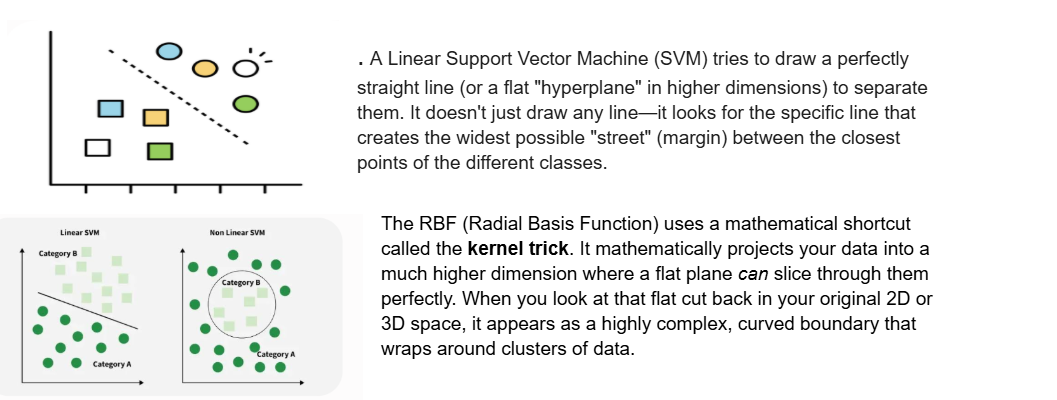

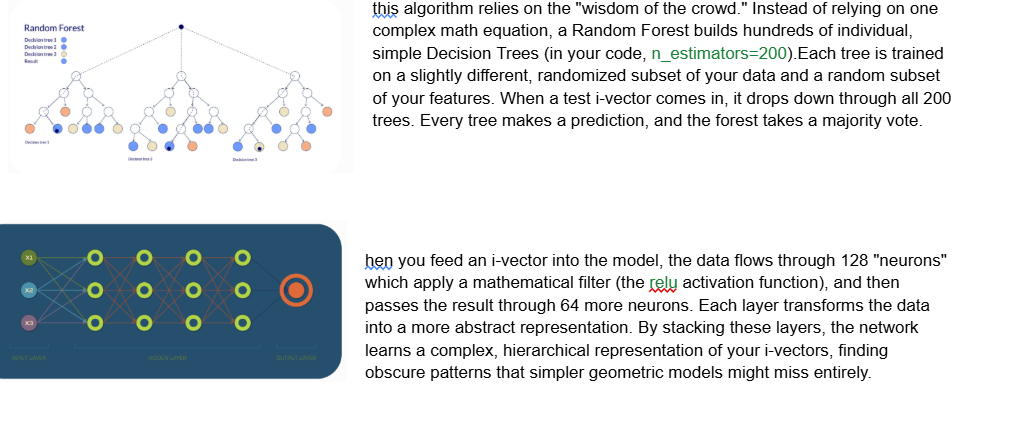

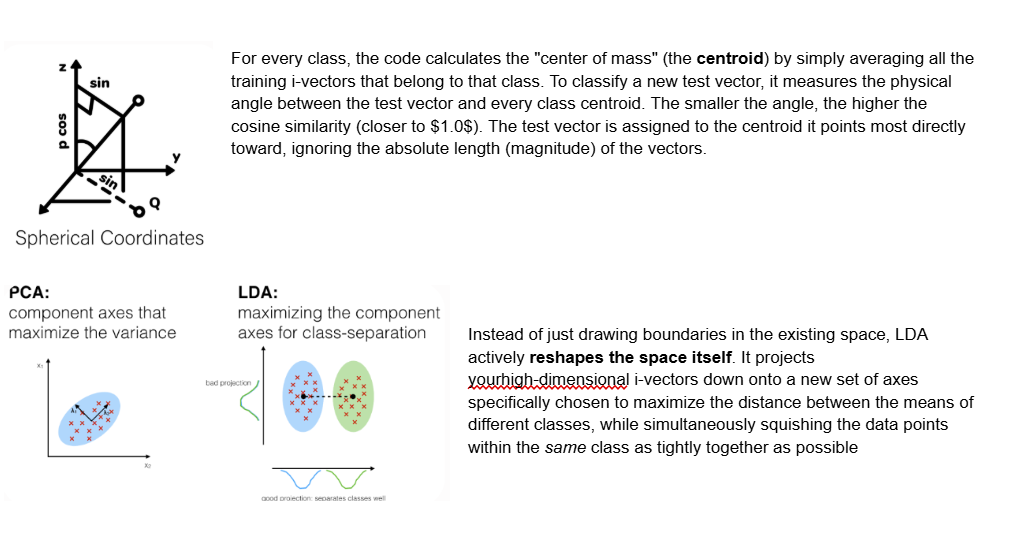

In [ ]:

# STEP 11: Train + evaluate SIX classifiers on the i-vectors
#
#   Generic ML classifiers layered on top of i-vectors:
#     Linear SVM, RBF SVM, Random Forest, DNN (MLP)
#   Classic i-vector-specific backends from the speaker
#   recognition literature:
#     Cosine similarity to class centroids, PLDA-style (LDA)

results = {}       # name -> accuracy
predictions = {}   # name -> predicted labels array (decoded strings, for plotting)

# --- Linear SVM ---
lin_clf = LinearSVC(dual=False, max_iter=5000, random_state=42)
lin_clf.fit(train_ivectors_norm, train_labels)
preds = lin_clf.predict(test_ivectors_norm)
predx = encoder.inverse_transform(preds)

results['Linear SVM'] = accuracy_score(test_labels, preds)
predictions['Linear SVM'] = predx

# --- RBF SVM ---
rbf_clf = SVC(kernel='rbf', C=1.0, cache_size=1000, random_state=42)
rbf_clf.fit(train_ivectors_norm, train_labels)
preds = rbf_clf.predict(test_ivectors_norm)
predx = encoder.inverse_transform(preds)
results['RBF SVM'] = accuracy_score(test_labels, preds)
predictions['RBF SVM'] = predx

# --- Random Forest ---
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_clf.fit(train_ivectors_norm, train_labels)
preds = rf_clf.predict(test_ivectors_norm)
predx = encoder.inverse_transform(preds)
results['Random Forest'] = accuracy_score(test_labels, preds)
predictions['Random Forest'] = predx

# --- DNN (small MLP) ---
dnn_clf = MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu',
                         max_iter=300, early_stopping=True, random_state=42)
dnn_clf.fit(train_ivectors_norm, train_labels)
preds = dnn_clf.predict(test_ivectors_norm)
predx = encoder.inverse_transform(preds)
results['DNN (MLP)'] = accuracy_score(test_labels, preds)
predictions['DNN (MLP)'] = predx

# --- Cosine similarity to class centroids ---
# No training beyond averaging: each class is represented by the
# mean of its training i-vectors; a test i-vector is assigned to
# whichever centroid it's most cosine-similar to.
unique_chars = sorted(set(train_labels))
train_labels_arr = np.array(train_labels)
centroids = np.array([
    train_ivectors_norm[train_labels_arr == c].mean(axis=0) for c in unique_chars
])
centroids = length_normalize(centroids)
sims = cosine_similarity(test_ivectors_norm, centroids)
cosine_preds = np.array(unique_chars)[np.argmax(sims, axis=1)]
predx = encoder.inverse_transform(cosine_preds)
results['Cosine similarity'] = accuracy_score(test_labels, cosine_preds)
predictions['Cosine similarity'] = predx

# --- PLDA-style (LDA) ---
# Full generative PLDA is built for verification ("same speaker or
# not"), not closed-set classification. For classification with
# labeled classes, it reduces to a Gaussian classifier with
# per-class means and one shared within-class covariance — which
# is exactly Fisher's Linear Discriminant Analysis.
plda_clf = LinearDiscriminantAnalysis()
plda_clf.fit(train_ivectors_norm, train_labels)
preds = plda_clf.predict(test_ivectors_norm)
predx = encoder.inverse_transform(preds)
results['PLDA-style (LDA)'] = accuracy_score(test_labels, preds)
predictions['PLDA-style (LDA)'] = predx

print("\nAccuracy by classifier:")
for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f"  {name}: {acc:.2%}")

best_name = max(results, key=results.get)
best_preds = predictions[best_name]  # decoded strings, for plotting
print(f"\nBest performer: {best_name} ({results[best_name]:.2%}) "
      f"— used for the confusion matrix and per-character plots below")


Accuracy by classifier:
  DNN (MLP): 89.70%
  RBF SVM: 89.52%
  Linear SVM: 87.16%
  PLDA-style (LDA): 85.44%
  Cosine similarity: 71.87%
  Random Forest: 69.24%

Best performer: DNN (MLP) (89.70%) — used for the confusion matrix and per-character plots below


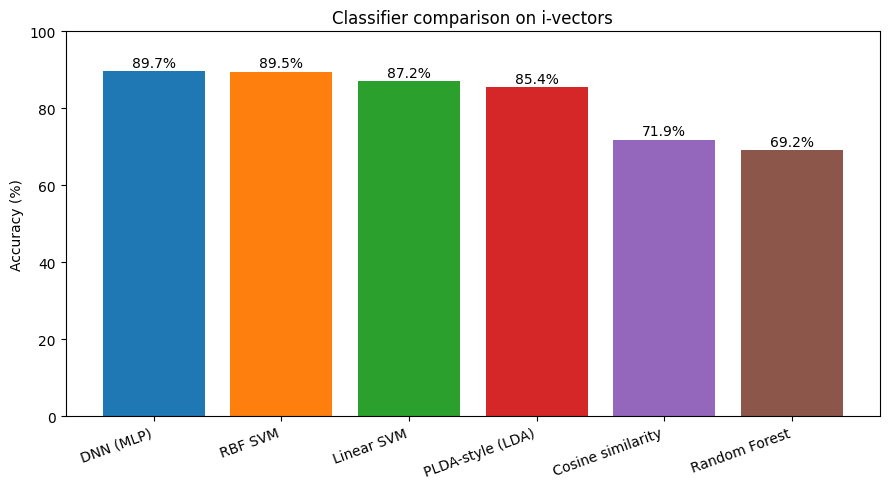

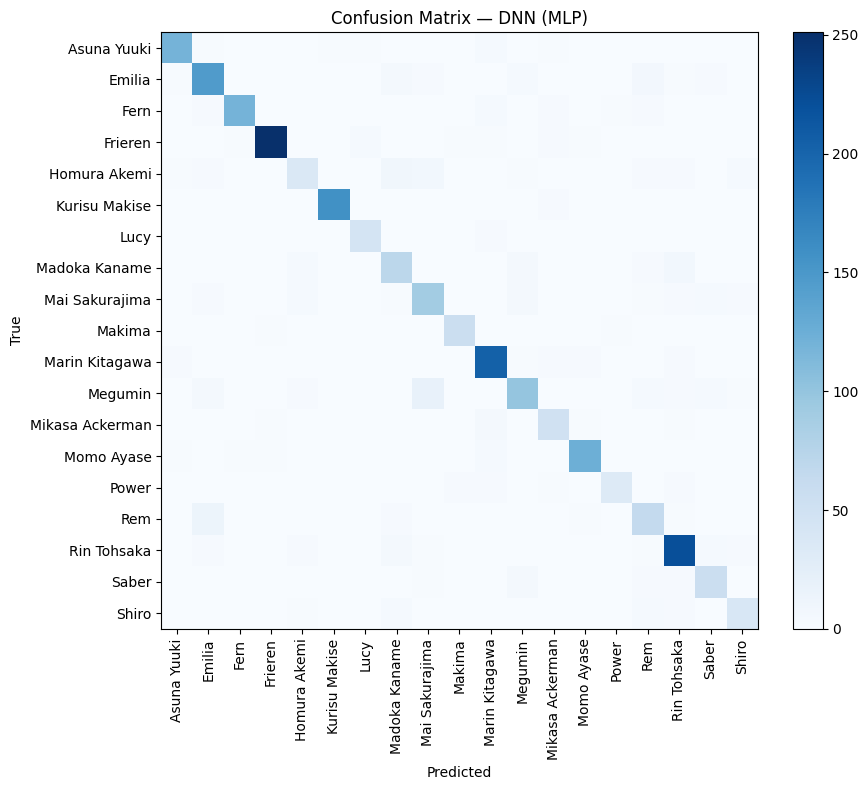

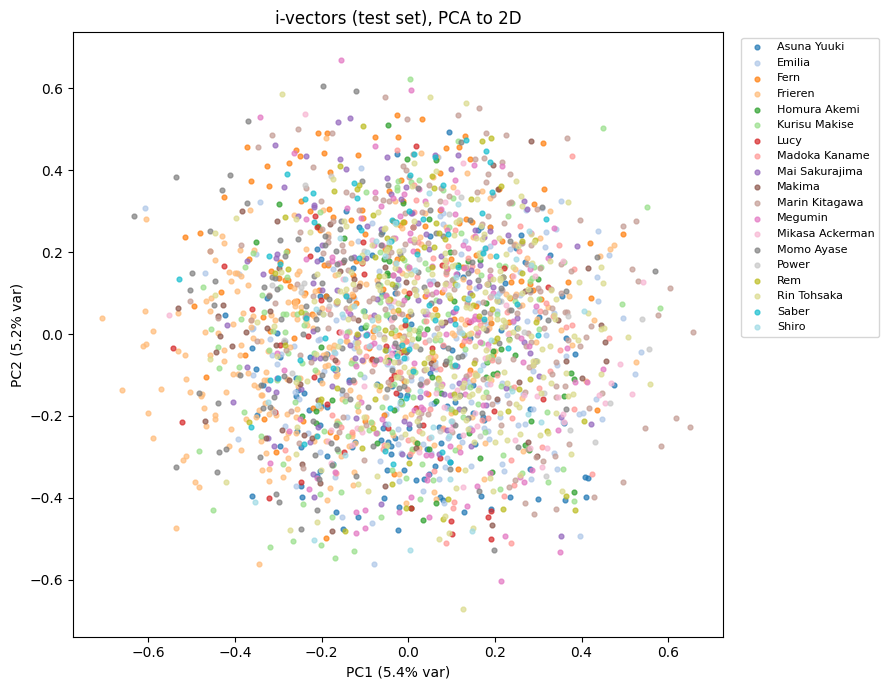

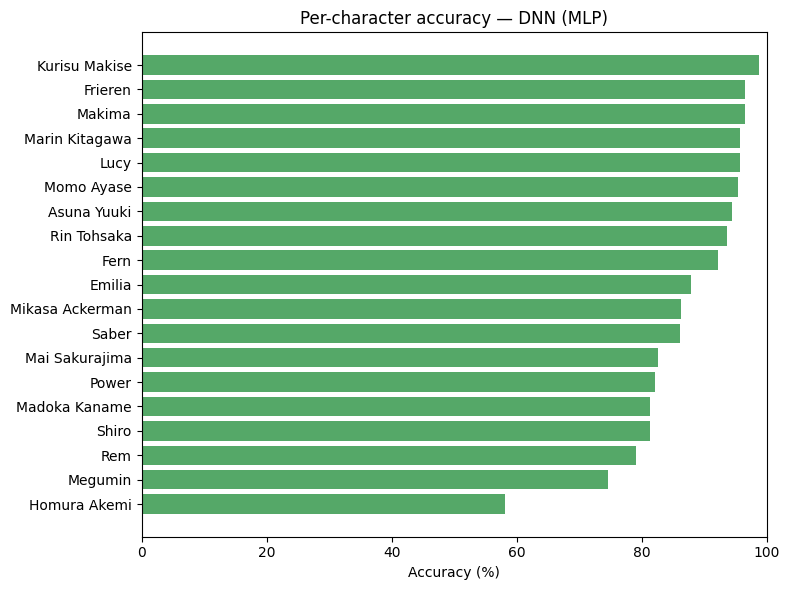

In [ ]:
# ============================================================
# STEP 12: Plots
# ============================================================

# --- Plot 1: accuracy comparison across all six classifiers ---
sorted_items = sorted(results.items(), key=lambda x: -x[1])
names = [n for n, _ in sorted_items]
accs = [a * 100 for _, a in sorted_items]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(names, accs, color=plt.get_cmap('tab10').colors[:len(names)])
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
ax.set_title('Classifier comparison on i-vectors')
plt.xticks(rotation=20, ha='right')
for bar in bars:
    h = bar.get_height()
    ax.annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3), textcoords='offset points', ha='center')
plt.tight_layout()
plt.show()

# --- Plot 2: confusion matrix for the best classifier ---
# FIX: use the decoded string labels consistently on both sides.
class_names = sorted(set(test_labels_str))
cm = confusion_matrix(test_labels_str, best_preds, labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=90)
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — {best_name}')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# --- Plot 3: i-vectors projected to 2D via PCA, colored by character ---
pca = PCA(n_components=2, random_state=42)
test_ivec_2d = pca.fit_transform(test_ivectors_norm)

fig, ax = plt.subplots(figsize=(9, 7))
unique_labels = sorted(set(test_labels_str))
cmap = plt.get_cmap('tab20', len(unique_labels))
test_labels_arr = np.array(test_labels_str)
for idx, char in enumerate(unique_labels):
    mask = test_labels_arr == char
    pts = test_ivec_2d[mask]
    ax.scatter(pts[:, 0], pts[:, 1], s=12, color=cmap(idx), label=char, alpha=0.7)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)')
ax.set_title('i-vectors (test set), PCA to 2D')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# --- Plot 4: per-character accuracy for the best classifier ---
char_correct = Counter()
char_total = Counter()
for t, p in zip(test_labels_str, best_preds):
    char_total[t] += 1
    if t == p:
        char_correct[t] += 1

chars_sorted = sorted(char_total.keys(), key=lambda c: char_correct[c] / char_total[c])
per_char_acc = [char_correct[c] / char_total[c] * 100 for c in chars_sorted]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(chars_sorted, per_char_acc, color='#55A868')
ax.set_xlabel('Accuracy (%)')
ax.set_title(f'Per-character accuracy — {best_name}')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()



In [ ]:
# ============================================================
# STEP 13: Summary
# ============================================================
print("\n" + "=" * 50)
print("SUMMARY")
print("=" * 50)
print(f"Original independent GMMs:  79.67%")
for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f"i-vector + {name}: {acc:.2%}")

## Quantitative Overlap Analysis for PCA Clusters

To identify characters with the most overlapping clusters, we will perform a quantitative analysis based on the 2D PCA projections. We will calculate the centroid for each character's cluster and then compute the pairwise Euclidean distances between these centroids. Character pairs with smaller distances are considered to have more overlapping clusters in the projected space.

In [ ]:
# Calculate centroids for each character's i-vectors in 2D PCA space
character_centroids = {}
for char_name in unique_labels:
    # Get indices for the current character
    mask = test_labels_str == char_name
    # Get the 2D i-vectors for this character
    char_ivecs_2d = test_ivec_2d[mask]
    # Calculate the centroid (mean) of these i-vectors
    if len(char_ivecs_2d) > 0:
        character_centroids[char_name] = np.mean(char_ivecs_2d, axis=0)
    else:
        character_centroids[char_name] = np.array([np.nan, np.nan]) # Handle cases with no data

# Convert centroids to a list of arrays and corresponding names for pairwise distance calculation
centroid_names = list(character_centroids.keys())
centroid_vectors = np.array([character_centroids[name] for name in centroid_names])

# Calculate pairwise Euclidean distances between centroids
from sklearn.metrics.pairwise import euclidean_distances
distances_matrix = euclidean_distances(centroid_vectors)

# Prepare to store and sort the distances for easier analysis
distance_pairs = []
for i in range(len(centroid_names)):
    for j in range(i + 1, len(centroid_names)): # Avoid self-comparison and duplicate pairs
        char1 = centroid_names[i]
        char2 = centroid_names[j]
        distance = distances_matrix[i, j]
        distance_pairs.append((distance, char1, char2))

# Sort pairs by distance in ascending order (smallest distance = most overlap)
distance_pairs.sort(key=lambda x: x[0])

print("Top 10 character pairs with the most overlapping clusters (smallest Euclidean distance between centroids in PCA space):")
for dist, char1, char2 in distance_pairs[:10]:
    print(f"  - {char1} and {char2}: Distance = {dist:.4f}")

# We can also look at the characters with the largest distances for least overlap
print("\nTop 10 character pairs with the least overlapping clusters (largest Euclidean distance between centroids in PCA space):")
for dist, char1, char2 in distance_pairs[-10:][::-1]: # Get last 10 and reverse for descending order
    print(f"  - {char1} and {char2}: Distance = {dist:.4f}")


## Detailed Performance Analysis and Misclassifications

To further understand the classifier's performance, let's look at per-character metrics (precision, recall, F1-score) and identify specific miscategorizations.

In [ ]:
from sklearn.metrics import classification_report
from collections import defaultdict

# Generate a classification report for the best classifier
# This gives precision, recall, and f1-score for each character
report = classification_report(test_labels_str, best_preds, target_names=class_names, output_dict=True, zero_division=0)

print(f"\n--- Per-Character Metrics ({best_name}) ---")
print(classification_report(test_labels_str, best_preds, target_names=class_names, zero_division=0))

# Identify specific miscategorizations
miscategorizations = defaultdict(Counter)
for true_label, predicted_label in zip(test_labels_str, best_preds):
    if true_label != predicted_label:
        miscategorizations[true_label][predicted_label] += 1

print("\n--- Top 10 Mischaracterizations ---")
# Flatten miscategorizations to sort them by count
miscategorization_list = []
for true_char, predicted_counts in miscategorizations.items():
    for predicted_char, count in predicted_counts.items():
        miscategorization_list.append((count, true_char, predicted_char))

miscategorization_list.sort(key=lambda x: x[0], reverse=True)

for i, (count, true_char, predicted_char) in enumerate(miscategorization_list[:10]):
    print(f"{i+1}. {true_char} was miscategorized as {predicted_char} {count} times.")

# Display overall metrics for context
print(f"\n--- Overall Metrics for {best_name} ---")
print(f"Overall Accuracy: {results[best_name]:.2%}")
print(f"Overall Precision (weighted avg): {report['weighted avg']['precision']:.2%}")
print(f"Overall Recall (weighted avg): {report['weighted avg']['recall']:.2%}")
print(f"Overall F1-Score (weighted avg): {report['weighted avg']['f1-score']:.2%}")

### Confusion Matrix Table

In [ ]:
import pandas as pd

# Create a DataFrame from the confusion matrix for better readability
confusion_matrix_df = pd.DataFrame(cm, index=class_names, columns=class_names)

print(f"\n--- Confusion Matrix ({best_name}) ---")
display(confusion_matrix_df)


--- Confusion Matrix (DNN (MLP)) ---


,Asuna Yuuki,Emilia,Fern,Frieren,Homura Akemi,Kurisu Makise,Lucy,Madoka Kaname,Mai Sakurajima,Makima,Marin Kitagawa,Megumin,Mikasa Ackerman,Momo Ayase,Power,Rem,Rin Tohsaka,Saber,Shiro
Asuna Yuuki,119,1,0,0,0,1,1,0,0,0,3,0,1,0,0,0,0,0,0
Emilia,1,146,0,0,0,0,0,5,2,0,0,3,0,0,0,6,1,2,0
Fern,0,2,119,0,0,0,0,0,0,0,3,0,2,0,1,2,0,0,0
Frieren,0,0,1,251,0,0,3,0,0,1,1,0,2,1,0,0,0,0,0
Homura Akemi,1,2,0,0,36,0,0,8,7,0,0,1,0,0,0,2,2,0,3
Kurisu Makise,0,0,0,0,0,157,0,0,0,0,0,0,2,0,0,0,0,0,0
Lucy,0,0,0,0,0,0,45,0,0,0,2,0,0,0,0,0,0,0,0
Madoka Kaname,0,0,0,0,3,0,0,70,0,0,0,4,0,0,0,2,7,0,0
Mai Sakurajima,0,2,0,0,3,0,0,1,90,0,0,5,0,0,0,1,2,3,2
Makima,0,0,0,1,0,0,0,0,0,55,0,0,0,0,1,0,0,0,0
